# Pointwise Area Comparison: Control vs Glaucoma (with/without Uramox)

Compare area between all three groups at **each time point** separately:
- CONTROL
- GLAUCOMA + URAMOX
- GLAUCOMA - URAMOX

**Method:**
- Pairwise Mann-Whitney U tests at each time point
- Benjamini-Hochberg FDR correction for multiple comparisons (across all tests)

**Prerequisites:** Run `01_data_processing.ipynb` first to generate the data files.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from pathlib import Path
from itertools import combinations

In [ ]:
RESULTS_DIR = Path('./results')
FIGURES_DIR = Path('./figures')
FIGURES_DIR.mkdir(exist_ok=True)
ALPHA = 0.05

# Project-wide colors (match 02, 03, 13, 15)
GROUP_ORDER = ['CONTROL', 'GLAUCOMA + URAMOX', 'GLAUCOMA - URAMOX']
group_colors = {
    'CONTROL': '#377EB8',
    'GLAUCOMA + URAMOX': '#4DAF4A',
    'GLAUCOMA - URAMOX': '#E41A1C',
}
LABEL_MAP = {
    'CONTROL': 'control',
    'GLAUCOMA + URAMOX': 'glaucoma with oral acetazolamide',
    'GLAUCOMA - URAMOX': 'glaucoma without oral acetazolamide',
}

COMPARISONS = [
    ('CONTROL', 'GLAUCOMA + URAMOX'),
    ('CONTROL', 'GLAUCOMA - URAMOX'),
    ('GLAUCOMA + URAMOX', 'GLAUCOMA - URAMOX')
]

## Load Data

In [15]:
df = pd.read_csv(RESULTS_DIR / 'eye_liquid_spread_measurements.csv')

df_area = df[(df['group'].notna()) & (df['area_cm2'].notna())].copy()
df_area = df_area[df_area['group'].isin(GROUP_ORDER)].copy()

print(f"Loaded {len(df_area)} area measurements")
print(f"Time points: {df_area['time_sec'].nunique()}")
print(f"\nCases per group:")
display(df_area.groupby('group')['case'].nunique())

Loaded 934 area measurements
Time points: 41

Cases per group:


group
CONTROL               8
GLAUCOMA + URAMOX    10
GLAUCOMA - URAMOX     5
Name: case, dtype: int64

## Pointwise Pairwise Mann-Whitney U Tests

In [16]:
time_points = sorted(df_area['time_sec'].unique())

results = []

for t in time_points:
    for group1, group2 in COMPARISONS:
        area1 = df_area[(df_area['group'] == group1) & (df_area['time_sec'] == t)]['area_cm2'].values
        area2 = df_area[(df_area['group'] == group2) & (df_area['time_sec'] == t)]['area_cm2'].values
        
        if len(area1) < 2 or len(area2) < 2:
            continue
        
        stat, pval = stats.mannwhitneyu(area1, area2, alternative='two-sided')
        
        results.append({
            'time_sec': t,
            'comparison': f"{LABEL_MAP.get(group1, group1)} vs {LABEL_MAP.get(group2, group2)}",
            'group1': group1,
            'group2': group2,
            'n_group1': len(area1),
            'n_group2': len(area2),
            'mean_group1': area1.mean(),
            'mean_group2': area2.mean(),
            'diff': area2.mean() - area1.mean(),
            'U_statistic': stat,
            'p_value': pval
        })

df_results = pd.DataFrame(results)
print(f"Performed {len(df_results)} tests ({len(time_points)} time points \u00d7 {len(COMPARISONS)} comparisons)")

Performed 123 tests (41 time points × 3 comparisons)


In [17]:
rejected, p_adjusted, _, _ = multipletests(df_results['p_value'], alpha=ALPHA, method='fdr_bh')

df_results['p_adjusted'] = p_adjusted
df_results['significant'] = rejected

print(f"Total tests: {len(df_results)}")
print(f"Significant after BH correction: {df_results['significant'].sum()}")

Total tests: 123
Significant after BH correction: 0


In [18]:
for comp in df_results['comparison'].unique():
    comp_results = df_results[df_results['comparison'] == comp]
    n_sig = comp_results['significant'].sum()
    print(f"\n{comp}: {n_sig}/{len(comp_results)} significant time points")
    
    if n_sig > 0:
        sig_times = comp_results[comp_results['significant']]['time_sec'].values
        print(f"  Significant at: {', '.join([f'{t:.2f}s' for t in sig_times])}")


CONTROL vs GLAUCOMA + URAMOX: 0/41 significant time points

CONTROL vs GLAUCOMA - URAMOX: 0/41 significant time points

GLAUCOMA + URAMOX vs GLAUCOMA - URAMOX: 0/41 significant time points


## Visualization

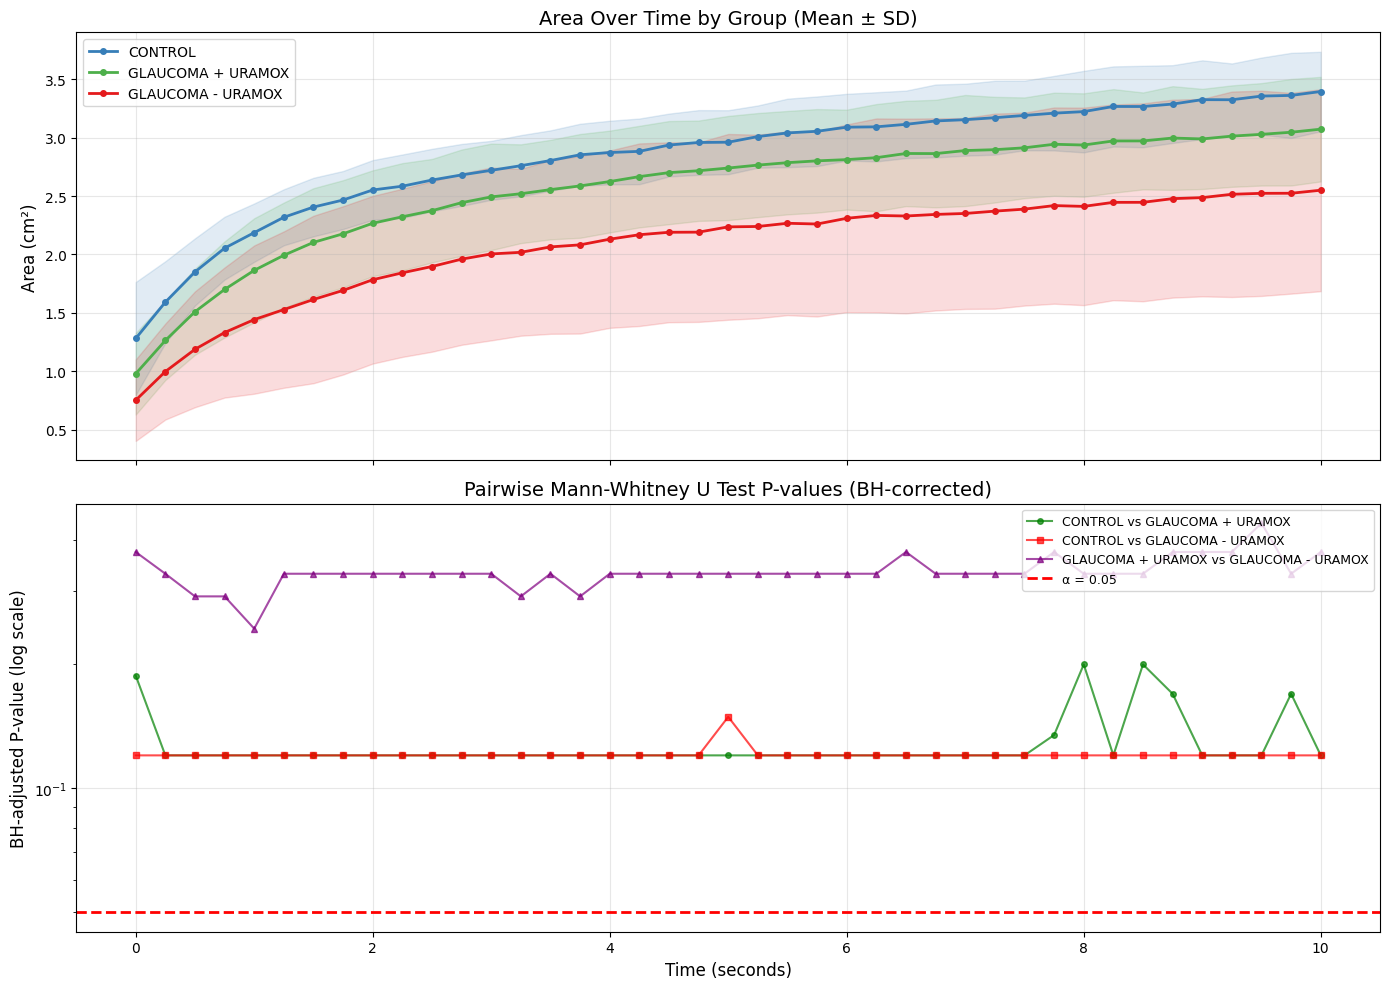

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
for group in GROUP_ORDER:
    group_data = df_area[df_area['group'] == group]
    stats_grp = group_data.groupby('time_sec')['area_cm2'].agg(['mean', 'std'])
    
    ax.plot(stats_grp.index, stats_grp['mean'], 'o-', label=LABEL_MAP.get(group, group), 
            color=group_colors[group], markersize=4, linewidth=2)
    ax.fill_between(stats_grp.index, 
                    stats_grp['mean'] - stats_grp['std'], 
                    stats_grp['mean'] + stats_grp['std'], 
                    alpha=0.15, color=group_colors[group])

ax.set_ylabel('Area (cm²)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
comp_styles = {
    'control vs glaucoma with oral acetazolamide': ('o-', 'green'),
    'control vs glaucoma without oral acetazolamide': ('s-', 'red'),
    'glaucoma with oral acetazolamide vs glaucoma without oral acetazolamide': ('^-', 'purple')
}

for comp in df_results['comparison'].unique():
    comp_results = df_results[df_results['comparison'] == comp]
    style, color = comp_styles.get(comp, ('o-', 'gray'))
    ax.semilogy(comp_results['time_sec'], comp_results['p_adjusted'], style, 
                color=color, label=comp, markersize=4, alpha=0.7)

ax.axhline(y=ALPHA, color='red', linestyle='--', linewidth=2, label=f'α = {ALPHA}')

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('BH-adjusted P-value (log scale)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '05a_area_over_time_mean_sd_pvalues.png', dpi=300, bbox_inches='tight')
plt.show()

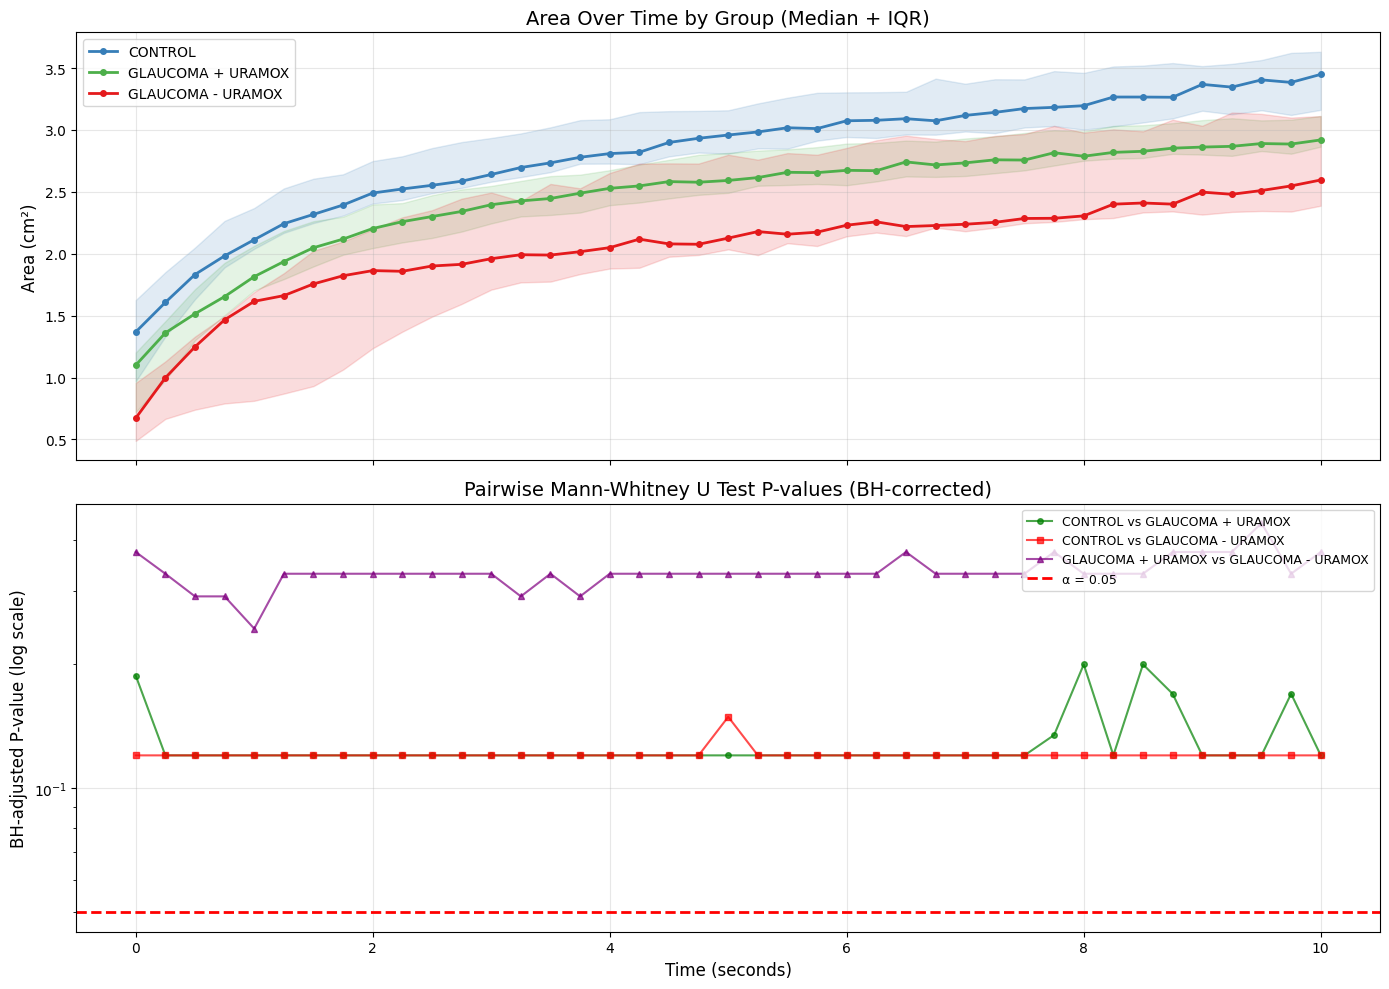

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
for group in GROUP_ORDER:
    group_data = df_area[df_area['group'] == group]
    stats_grp = group_data.groupby('time_sec')['area_cm2'].agg(
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    
    ax.plot(stats_grp.index, stats_grp['median'], 'o-', label=LABEL_MAP.get(group, group), 
            color=group_colors[group], markersize=4, linewidth=2)
    ax.fill_between(stats_grp.index, 
                    stats_grp['q25'], 
                    stats_grp['q75'], 
                    alpha=0.15, color=group_colors[group])

ax.set_ylabel('Area (cm²)', fontsize=12)
ax.set_title('Area over time by group (median + IQR)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
comp_styles = {
    'control vs glaucoma with oral acetazolamide': ('o-', 'green'),
    'control vs glaucoma without oral acetazolamide': ('s-', 'red'),
    'glaucoma with oral acetazolamide vs glaucoma without oral acetazolamide': ('^-', 'purple')
}

for comp in df_results['comparison'].unique():
    comp_results = df_results[df_results['comparison'] == comp]
    style, color = comp_styles.get(comp, ('o-', 'gray'))
    ax.semilogy(comp_results['time_sec'], comp_results['p_adjusted'], style, 
                color=color, label=comp, markersize=4, alpha=0.7)

ax.axhline(y=ALPHA, color='red', linestyle='--', linewidth=2, label=f'α = {ALPHA}')

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('BH-adjusted p-value (log scale)', fontsize=12)
ax.set_title('Pairwise Mann-Whitney U test p-values (BH-corrected)', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '05a_area_over_time_median_iqr_pvalues.png', dpi=300, bbox_inches='tight')
plt.show()

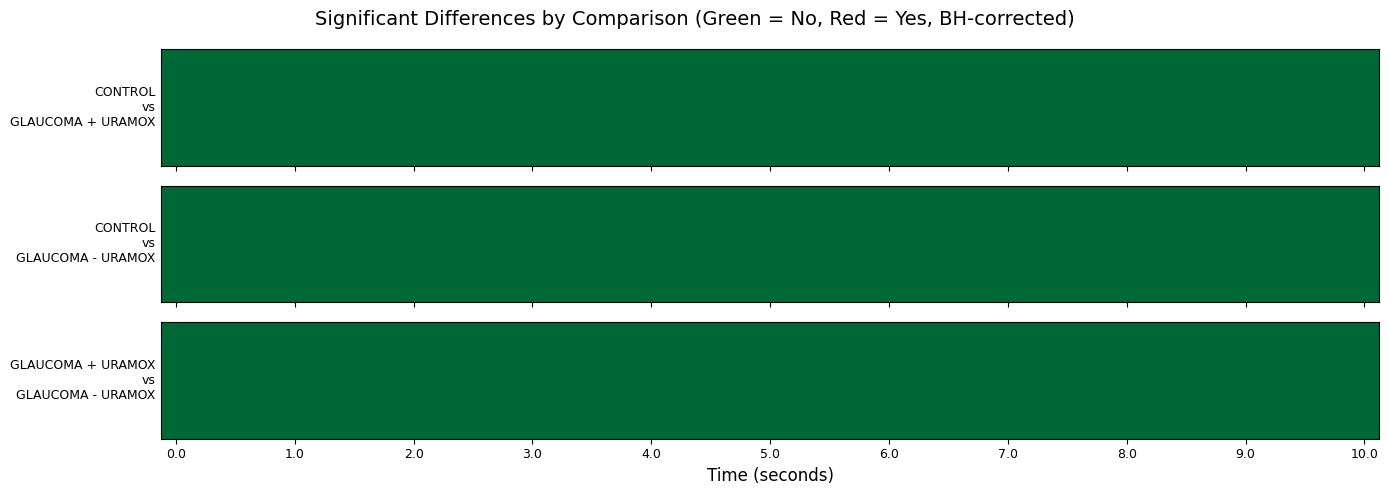

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)

for idx, comp in enumerate(df_results['comparison'].unique()):
    ax = axes[idx]
    comp_results = df_results[df_results['comparison'] == comp].sort_values('time_sec')
    
    sig_array = comp_results['significant'].values.reshape(1, -1).astype(int)
    im = ax.imshow(sig_array, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
    
    ax.set_yticks([])
    ax.set_ylabel(comp.replace(' vs ', '\nvs\n'), fontsize=9, rotation=0, ha='right', va='center')
    
    if idx == len(COMPARISONS) - 1:
        ax.set_xticks(range(0, len(comp_results), 4))
        ax.set_xticklabels([f"{t:.1f}" for t in comp_results['time_sec'].values[::4]], fontsize=9)
        ax.set_xlabel('Time (seconds)', fontsize=12)
    else:
        ax.set_xticks([])

fig.suptitle('Significant Differences by Comparison (Green = No, Red = Yes, BH-corrected)', fontsize=14)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '05a_area_significance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Conclusions

In [22]:
print("="*70)
print("POINTWISE AREA COMPARISON: CONTROL vs GLAUCOMA (+/- URAMOX)")
print("="*70)

n_tests = len(df_results)
n_sig = df_results['significant'].sum()

print(f"\nTotal tests performed: {n_tests}")
print(f"  ({len(time_points)} time points \u00d7 {len(COMPARISONS)} pairwise comparisons)")
print(f"\nSignificant after BH correction: {n_sig} ({100*n_sig/n_tests:.1f}%)")

for comp in COMPARISONS:
    comp_str = f"{LABEL_MAP.get(comp[0], comp[0])} vs {LABEL_MAP.get(comp[1], comp[1])}"
    comp_results = df_results[df_results['comparison'] == comp_str]
    n_sig_comp = comp_results['significant'].sum()
    
    print(f"\n" + "="*70)
    print(f"{comp_str.upper()}")
    print("="*70)
    
    if n_sig_comp > 0:
        sig_results = comp_results[comp_results['significant']].copy()
        
        print(f"\nSignificant time points: {n_sig_comp}/{len(comp_results)}")
        print(f"Time range: {sig_results['time_sec'].min():.2f}s - {sig_results['time_sec'].max():.2f}s")
        
        mean_diff = sig_results['diff'].mean()
        direction = "larger" if mean_diff > 0 else "smaller"
        print(f"\nMean area difference at significant time points:")
        print(f"  {comp[1]} is {abs(mean_diff):.4f} cm\u00b2 {direction} than {comp[0]}")
        
        print(f"\nDetails by time point:")
        for _, row in sig_results.iterrows():
            dir_str = "\u2191" if row['diff'] > 0 else "\u2193"
            print(f"  t={row['time_sec']:.2f}s: {row['mean_group1']:.4f} vs {row['mean_group2']:.4f} "
                  f"(diff={row['diff']:+.4f} {dir_str}, p_adj={row['p_adjusted']:.4f})")
    else:
        print(f"\nNo significant differences found after BH correction.")
        min_p_row = comp_results.loc[comp_results['p_adjusted'].idxmin()]
        print(f"Closest to significance: t={min_p_row['time_sec']:.2f}s (p_adj={min_p_row['p_adjusted']:.4f})")

POINTWISE AREA COMPARISON: CONTROL vs GLAUCOMA (+/- URAMOX)

Total tests performed: 123
  (41 time points × 3 pairwise comparisons)

Significant after BH correction: 0 (0.0%)

CONTROL VS GLAUCOMA + URAMOX

No significant differences found after BH correction.
Closest to significance: t=0.25s (p_adj=0.1201)

CONTROL VS GLAUCOMA - URAMOX

No significant differences found after BH correction.
Closest to significance: t=0.00s (p_adj=0.1201)

GLAUCOMA + URAMOX VS GLAUCOMA - URAMOX

No significant differences found after BH correction.
Closest to significance: t=1.00s (p_adj=0.2438)


In [23]:
print("\n" + "="*70)
print("SUMMARY CONCLUSIONS")
print("="*70)

for comp in COMPARISONS:
    comp_str = f"{LABEL_MAP.get(comp[0], comp[0])} vs {LABEL_MAP.get(comp[1], comp[1])}"
    comp_results = df_results[df_results['comparison'] == comp_str]
    sig_results = comp_results[comp_results['significant']]
    
    if len(sig_results) > 0:
        time_range = f"{sig_results['time_sec'].min():.2f}s-{sig_results['time_sec'].max():.2f}s"
        mean_diff = sig_results['diff'].mean()
        direction = "larger" if mean_diff > 0 else "smaller"
        print(f"\n\u2022 {comp_str}:")
        print(f"  SIGNIFICANT at {len(sig_results)} time points ({time_range})")
        print(f"  {comp[1]} area is {direction} than {comp[0]}")
    else:
        print(f"\n\u2022 {comp_str}:")
        print(f"  No significant differences found")


SUMMARY CONCLUSIONS

• CONTROL vs GLAUCOMA + URAMOX:
  No significant differences found

• CONTROL vs GLAUCOMA - URAMOX:
  No significant differences found

• GLAUCOMA + URAMOX vs GLAUCOMA - URAMOX:
  No significant differences found


In [24]:
output_path = RESULTS_DIR / 'pointwise_area_control_vs_glaucoma_uramox.csv'
df_results.to_csv(output_path, index=False)
print(f"\nResults saved to: {output_path}")


Results saved to: results\pointwise_area_control_vs_glaucoma_uramox.csv
